### **What Leads to Wins in College Basketball?**

**Loading Dataset:**

In [17]:
##1 Import pandas
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


##2 Load CSV called cbb26.csv
cbb26 = pd.read_csv("cbb26.csv")


# Allow for all columns to be seen
pd.set_option('display.max_columns', 70)

In [18]:
cbb26.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 23 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   RK       365 non-null    int64  
 1   TEAM     365 non-null    object 
 2   CONF     365 non-null    object 
 3   G        365 non-null    int64  
 4   W        365 non-null    int64  
 5   ADJOE    365 non-null    float64
 6   ADJDE    365 non-null    float64
 7   BARTHAG  365 non-null    float64
 8   EFG_O    365 non-null    float64
 9   EFG_D    365 non-null    float64
 10  TOR      365 non-null    float64
 11  TORD     365 non-null    float64
 12  ORB      365 non-null    float64
 13  DRB      365 non-null    float64
 14  FTR      365 non-null    float64
 15  FTRD     365 non-null    float64
 16  2P_O     365 non-null    float64
 17  2P_D     365 non-null    float64
 18  3P_O     365 non-null    float64
 19  3P_D     365 non-null    float64
 20  ADJ_T    365 non-null    float64
 21  WAB      365 non

**What every column means:**
- TEAM = Team name
- CONF = Conference team is in
- G = Games
- W = Wins
- ADJOE = Adjusted Offensive Efficiency
- ADJDE = Adjusted Defensive Efficiency
- BARTHAG = Power rating estimating the probability the team would beat an average Division I team
- EFG-O = Effective Field Goal Percentage
- EFG-D = Effective Field Goal Percentage Allowed
- TOR = Turnover Rate
- TORD = Turnover Rate Allowed
- ORB = Offensive Rebounds
- DRB = Defensive Rebounds
- FTR = Free Throw Rate
- FTRD = Free Throw Rate Allowed
- 2P-O = 2-Point Field Goal Percentage
- 2P-D = 2-Point Field Goal Percentage Allowed
- 3P-O = 3-Point Field Goal Percentage
- 3P-D = 3-Point Field Goal Percentage Allowed
- ADJ-T = Adjusted Tempo
- WAB = Wins Above Bubble
- SEED = March Madness Seed

**The Facts about the 2026 College Basketball Season:**
- Champion - Michigan
- Runner-Up - UConn
- Final Four Losers - Arizona and Illinois
- No. 1 Seeds - Michigan, Arizona, Duke, and Florida
- Conference Champions - Duke (ACC), Arizona (B12), Purdue (B10), Arkansas (SEC), St. John's (BE)

**What Each Scatterplot Shows:**
*   A point for every Division 1 team
*   A trendline showing the relationship between wins and the other statistic
*   Highlighted points for the four team in the Final Four (Gold = Michigan, Blue = UConn, Red = Arizona, Orange = Illinois)



**What Each Ranking Shows:**
*    The rankings only include Power Conference Teams (SEC, ACC, Big 10, Big 12, Big East)
*    The top 20 and bottom 10 teams at that Statistic
*    The Seed of each team
*    The Conference of each team
*    The number of wins for each team
*    The value for the Statistic that is being ranked

**Setting Power Conferences:**

In [19]:
power_conferences = ["SEC", "ACC", "B10", "B12", "BE"]
powercbb26 = cbb26[cbb26["CONF"].isin(power_conferences)]

**Adjusted Offensive Efficiency:**

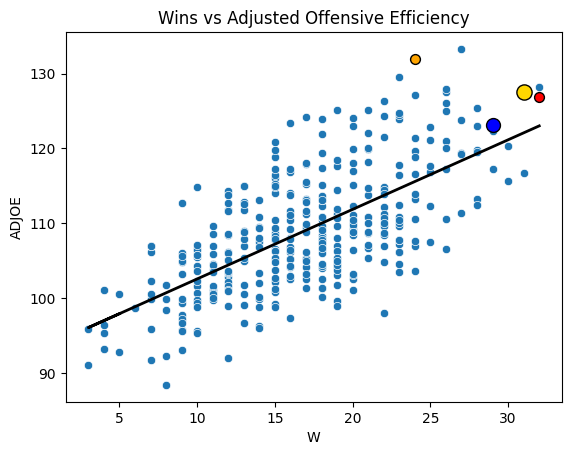

In [20]:
# Plot every team
sns.scatterplot(data=cbb26, x="W", y="ADJOE")
plt.title("Wins vs Adjusted Offensive Efficiency")

# Trendline
x = cbb26["W"]
y = cbb26["ADJOE"]

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='black', linewidth=2)

# Highlight Michigan
michigan = cbb26[cbb26["TEAM"] == "Michigan"]
plt.scatter(
    michigan["W"],
    michigan["ADJOE"],
    color="gold",
    edgecolors="black",
    s=120,
    zorder=10
)

# Highlight UConn
uconn = cbb26[cbb26["TEAM"] == "Connecticut"]
plt.scatter(
    uconn["W"],
    uconn["ADJOE"],
    color="blue",
    edgecolors="black",
    s=100,
    zorder=10
)

# Highlight Arizona
arizona = cbb26[cbb26["TEAM"] == "Arizona"]
plt.scatter(
    arizona["W"],
    arizona["ADJOE"],
    color="red",
    edgecolors="black",
    s=50,
    zorder=10
)

# Highlight Illinois
illinois = cbb26[cbb26["TEAM"] == "Illinois"]
plt.scatter(
    illinois["W"],
    illinois["ADJOE"],
    color="orange",
    edgecolors="black",
    s=50,
    zorder=10
)

This scatterplot shows a clear positive relationship between wins and Adjusted Offensive Efficiency. As a team's offensive efficiency increases, their number of wins generally increases as well. The four Final Four teams are all toward the higher end of the graph, showing that having a strong offense was important for the most successful teams in 2026.



**What Team had the Best Adjusted Offensive Efficiency in a Power Conference in 2026?**

In [21]:
top_offenses = powercbb26.sort_values(by="ADJOE", ascending=False)
print("20 Best Adjusted Offensive Efficiency")
print(top_offenses[["SEED", "CONF", "W", "TEAM", "ADJOE"]].head(20))

20 Best Adjusted Offensive Efficiency
    SEED CONF   W        TEAM  ADJOE
7    2.0  B10  27      Purdue  133.3
5    3.0  B10  24    Illinois  131.9
17   4.0  SEC  23     Alabama  129.5
0    1.0  ACC  32        Duke  128.2
18   4.0  SEC  26    Arkansas  127.9
1    1.0  B10  31    Michigan  127.6
9    5.0  SEC  26  Vanderbilt  127.5
20   5.0  B10  24   Wisconsin  127.2
2    1.0  B12  32     Arizona  126.9
11   5.0  B12  22  Texas Tech  126.3
3    1.0  SEC  26     Florida  126.1
4    2.0  B12  28     Houston  125.4
22   8.0  B10  21    Ohio St.  125.2
38   NaN  SEC  19    Oklahoma  125.2
32   6.0  B12  23         BYU  124.7
23   7.0  B10  23        UCLA  124.5
36   8.0  SEC  22     Georgia  124.3
40   NaN  SEC  17      Auburn  124.2
37  11.0  ACC  20  N.C. State  124.1
16   6.0  ACC  23  Louisville  124.0


This ranking shows the top 20 teams in a Power Conference at Adjusted Offensive Efficiency. Looking at the ranking, you can see that most of the teams were highly seeded, with all four one seeds appearing in the top 12. This shows that having a strong offense was common among the best teams in college basketball.

**What Team had the Worst Adjusted Offensive Efficiency in a Power Conference in 2026?**

In [22]:
worst_offenses = powercbb26.sort_values(by="ADJOE", ascending=True)
print("10 Worst Adjusted Offensive Efficiency")
print(worst_offenses[["SEED", "CONF", "W", "TEAM", "ADJOE"]].head(10))

10 Worst Adjusted Offensive Efficiency
     SEED CONF   W            TEAM  ADJOE
138   NaN  ACC  11  Boston College  103.7
100   NaN   BE  16          DePaul  106.8
161   NaN  ACC  11    Georgia Tech  106.9
61    NaN  B12  18   West Virginia  108.5
59    NaN   BE  21      Seton Hall  108.7
116   NaN  B10  14         Rutgers  110.9
112   NaN  B10  12        Maryland  111.7
76    NaN   BE  12       Marquette  111.8
89    NaN  B10  12          Oregon  111.8
99    NaN  SEC  13  South Carolina  111.8


This ranking shows the 10 worst teams in a Power Conference at Adjusted Offensive Efficiency. None of these teams made the NCAA Tournament, and most had fewer than 20 wins. This shows that having a very poor offense made it difficult for teams to be successful.

**Adjusted Defensive Efficiency:**

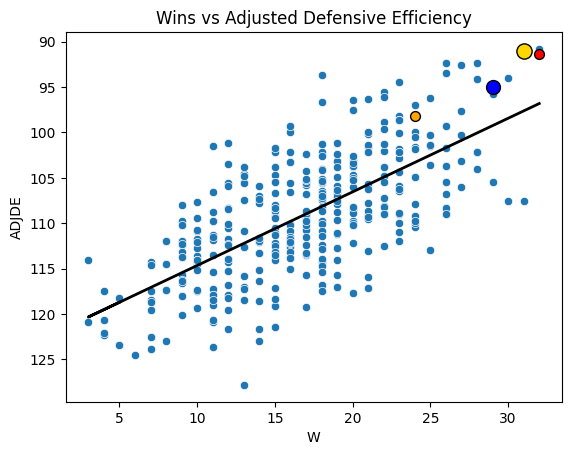

In [23]:
# Plot every team
sns.scatterplot(data=cbb26, x="W", y="ADJDE")
plt.title("Wins vs Adjusted Defensive Efficiency")

# Trendline
x = cbb26["W"]
y = cbb26["ADJDE"]

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='black', linewidth=2)

# Highlight Michigan
michigan = cbb26[cbb26["TEAM"] == "Michigan"]
plt.scatter(
    michigan["W"],
    michigan["ADJDE"],
    color="gold",
    edgecolors="black",
    s=120,
    zorder=10
)

# Highlight UConn
uconn = cbb26[cbb26["TEAM"] == "Connecticut"]
plt.scatter(
    uconn["W"],
    uconn["ADJDE"],
    color="blue",
    edgecolors="black",
    s=100,
    zorder=10
)

# Highlight Arizona
arizona = cbb26[cbb26["TEAM"] == "Arizona"]
plt.scatter(
    arizona["W"],
    arizona["ADJDE"],
    color="red",
    edgecolors="black",
    s=50,
    zorder=10
)

# Highlight Illinois
illinois = cbb26[cbb26["TEAM"] == "Illinois"]
plt.scatter(
    illinois["W"],
    illinois["ADJDE"],
    color="orange",
    edgecolors="black",
    s=50,
    zorder=10
)

# Inverting the Y axis to make the Trendline Positive
plt.gca().invert_yaxis()

This scatterplot shows a negative relationship between wins and Adjusted Defensive Efficiency. Since a lower number means better defensive efficiency, the teams with more wins generally had better defenses. The Final Four teams were all among the better defensive teams, showing that strong defense was an important part of their success.

**What Team had the Best Adjusted Defensive Efficiency in a Power Conference in 2026?**

In [24]:
top_defense = powercbb26.sort_values(by="ADJDE", ascending=True)
print("20 Best Adjusted Defensive Efficiency")
print(top_defense[["SEED", "CONF", "W", "TEAM", "ADJDE"]].head(20))

20 Best Adjusted Defensive Efficiency
    SEED CONF   W           TEAM  ADJDE
0    1.0  ACC  32           Duke   90.8
1    1.0  B10  31       Michigan   91.0
2    1.0  B12  32        Arizona   91.4
3    1.0  SEC  26        Florida   92.3
4    2.0  B12  28        Houston   92.4
6    2.0  B12  27       Iowa St.   92.6
19   4.0  B10  26       Nebraska   93.5
31   NaN  B12  18     Cincinnati   93.7
14   5.0   BE  28     St. John's   94.1
21   4.0  B12  23         Kansas   94.4
8    2.0   BE  29    Connecticut   95.0
15   6.0  SEC  22      Tennessee   95.5
13   3.0  ACC  29       Virginia   95.8
12   3.0  B10  25   Michigan St.   96.2
59   NaN   BE  21     Seton Hall   96.3
61   NaN  B12  18  West Virginia   96.6
29   8.0  ACC  24        Clemson   97.0
5    3.0  B10  24       Illinois   98.2
16   6.0  ACC  23     Louisville   98.2
11   5.0  B12  22     Texas Tech   98.8


This ranking shows the top 20 teams in a Power Conference at Adjusted Defensive Efficiency. The top six teams were all one or two seeds, showing a strong relationship between having a good defense and being one of the best teams in the country. Cincinnati is a notable outlier because they had a strong defense but only 18 wins.

**What Team had the Worst Adjusted Defensive Efficiency in a Power Conference in 2026?**

In [25]:
worst_defense = powercbb26.sort_values(by="ADJDE", ascending=False)
print("10 Worst Adjusted Defensive Efficiency")
print(worst_defense[["SEED", "CONF", "W", "TEAM", "ADJDE"]].head(10))

10 Worst Adjusted Defensive Efficiency
     SEED CONF   W          TEAM  ADJDE
140   NaN  B10  12      Penn St.  111.7
114   NaN  B12  10          Utah  109.4
93    NaN   BE  15        Xavier  109.3
73    NaN   BE  15    Providence  109.2
96    NaN  ACC  13    Notre Dame  107.4
74    NaN  B12  19  Oklahoma St.  107.2
75    NaN  B12  17      Colorado  106.8
69    NaN  SEC  15           LSU  106.7
46    NaN  B12  16        Baylor  106.6
161   NaN  ACC  11  Georgia Tech  106.6


This ranking shows the 10 worst teams in a Power Conference at Adjusted Defensive Efficiency. None of these teams made the NCAA Tournament, and most had relatively low win totals. This shows that having a poor defense can make it very difficult for a team to consistently win games.

**BARTHAG:**

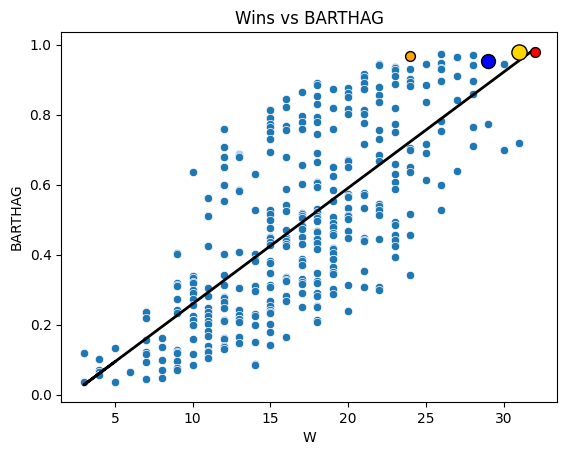

In [26]:
# Plot every team
sns.scatterplot(data=cbb26, x="W", y="BARTHAG")
plt.title("Wins vs BARTHAG")

# Trendline
x = cbb26["W"]
y = cbb26["BARTHAG"]

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='black', linewidth=2)

# Highlight Michigan
michigan = cbb26[cbb26["TEAM"] == "Michigan"]
plt.scatter(
    michigan["W"],
    michigan["BARTHAG"],
    color="gold",
    edgecolors="black",
    s=120,
    zorder=10
)

# Highlight UConn
uconn = cbb26[cbb26["TEAM"] == "Connecticut"]
plt.scatter(
    uconn["W"],
    uconn["BARTHAG"],
    color="blue",
    edgecolors="black",
    s=100,
    zorder=10
)

# Highlight Arizona
arizona = cbb26[cbb26["TEAM"] == "Arizona"]
plt.scatter(
    arizona["W"],
    arizona["BARTHAG"],
    color="red",
    edgecolors="black",
    s=50,
    zorder=10
)

# Highlight Illinois
illinois = cbb26[cbb26["TEAM"] == "Illinois"]
plt.scatter(
    illinois["W"],
    illinois["BARTHAG"],
    color="orange",
    edgecolors="black",
    s=50,
    zorder=10
)

This scatterplot shows a very strong positive relationship between wins and BARTHAG. Teams with higher BARTHAG ratings generally had more wins. All four Final Four teams were near the top of this statistic, showing that BARTHAG was strongly connected to team success in the 2026 season.

**What Team had the Best BARTHAG in a Power Conference in 2026?**

In [27]:
top_barthag = powercbb26.sort_values(by="BARTHAG", ascending=False)
print("20 Best BARTHAG")
print(top_barthag[["SEED", "CONF", "W", "TEAM", "BARTHAG"]].head(20))

20 Best BARTHAG
    SEED CONF   W          TEAM  BARTHAG
0    1.0  ACC  32          Duke   0.9813
1    1.0  B10  31      Michigan   0.9799
2    1.0  B12  32       Arizona   0.9776
3    1.0  SEC  26       Florida   0.9732
4    2.0  B12  28       Houston   0.9709
5    3.0  B10  24      Illinois   0.9676
6    2.0  B12  27      Iowa St.   0.9655
7    2.0  B10  27        Purdue   0.9636
8    2.0   BE  29   Connecticut   0.9518
9    5.0  SEC  26    Vanderbilt   0.9461
11   5.0  B12  22    Texas Tech   0.9439
12   3.0  B10  25  Michigan St.   0.9437
13   3.0  ACC  29      Virginia   0.9427
14   5.0   BE  28    St. John's   0.9415
15   6.0  SEC  22     Tennessee   0.9408
16   6.0  ACC  23    Louisville   0.9364
17   4.0  SEC  23       Alabama   0.9344
18   4.0  SEC  26      Arkansas   0.9337
19   4.0  B10  26      Nebraska   0.9310
20   5.0  B10  24     Wisconsin   0.9294


This ranking shows the top 20 teams in a Power Conference at BARTHAG, which estimates the probability that a team would beat an average Division I team. All 20 teams were seeded sixth or higher in the NCAA Tournament, showing that BARTHAG was very strongly connected to how successful teams were in 2026.

**What Team had the Worst BARTHAG in a Power Conference in 2026?**





In [28]:
worst_barthag = powercbb26.sort_values(by="BARTHAG", ascending=True)
print("10 Worst BARTHAG")
print(worst_barthag[["SEED", "CONF", "W", "TEAM", "BARTHAG"]].head(10))

10 Worst BARTHAG
     SEED CONF   W            TEAM  BARTHAG
161   NaN  ACC  11    Georgia Tech   0.5093
140   NaN  B10  12        Penn St.   0.5520
138   NaN  ACC  11  Boston College   0.5621
116   NaN  B10  14         Rutgers   0.6297
114   NaN  B12  10            Utah   0.6367
112   NaN  B10  12        Maryland   0.6496
102   NaN  ACC  13      Pittsburgh   0.6782
101   NaN  B12  12      Kansas St.   0.6783
100   NaN   BE  16          DePaul   0.6798
99    NaN  SEC  13  South Carolina   0.6811


This ranking shows the 10 worst teams in a Power Conference at BARTHAG. None of these teams made the NCAA Tournament, and all had relatively low win totals. This shows that teams that are not likely to beat an average Division I team generally struggled to have successful seasons.

**Effective Field Goal Percentage:**

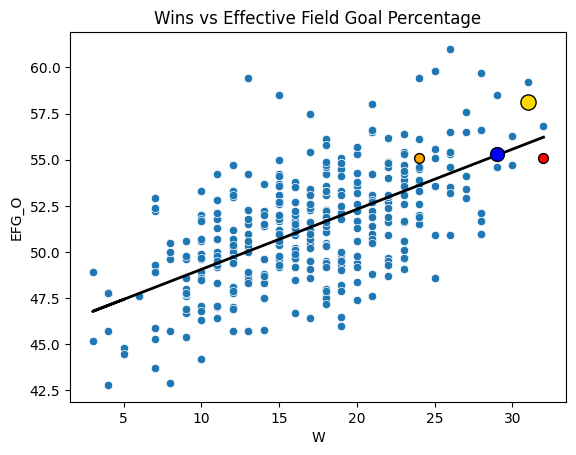

In [29]:
# Plot every team
sns.scatterplot(data=cbb26, x="W", y="EFG_O")
plt.title("Wins vs Effective Field Goal Percentage")

# Trendline
x = cbb26["W"]
y = cbb26["EFG_O"]

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='black', linewidth=2)

# Highlight Michigan
michigan = cbb26[cbb26["TEAM"] == "Michigan"]
plt.scatter(
    michigan["W"],
    michigan["EFG_O"],
    color="gold",
    edgecolors="black",
    s=120,
    zorder=10
)

# Highlight UConn
uconn = cbb26[cbb26["TEAM"] == "Connecticut"]
plt.scatter(
    uconn["W"],
    uconn["EFG_O"],
    color="blue",
    edgecolors="black",
    s=100,
    zorder=10
)

# Highlight Arizona
arizona = cbb26[cbb26["TEAM"] == "Arizona"]
plt.scatter(
    arizona["W"],
    arizona["EFG_O"],
    color="red",
    edgecolors="black",
    s=50,
    zorder=10
)

# Highlight Illinois
illinois = cbb26[cbb26["TEAM"] == "Illinois"]
plt.scatter(
    illinois["W"],
    illinois["EFG_O"],
    color="orange",
    edgecolors="black",
    s=50,
    zorder=10
)

This scatterplot shows a positive relationship between wins and Effective Field Goal Percentage. Teams that were more efficient at scoring generally won more games. The Final Four teams were all toward the higher end of the graph, showing that efficient shooting was an important part of having a successful season.

**What Team had the Best Effective Field Goal Percentage in a Power Conference in 2026?**

In [30]:
top_efgo = powercbb26.sort_values(by="EFG_O", ascending=False)
print("20 Best Effective Field Goal Percentage")
print(top_efgo[["SEED", "CONF", "W", "TEAM", "EFG_O"]].head(20))

20 Best Effective Field Goal Percentage
    SEED CONF   W         TEAM  EFG_O
1    1.0  B10  31     Michigan   58.1
7    2.0  B10  27       Purdue   57.6
0    1.0  ACC  32         Duke   56.8
25   9.0  B10  21         Iowa   56.6
6    2.0  B12  27     Iowa St.   56.5
18   4.0  SEC  26     Arkansas   56.5
22   8.0  B10  21     Ohio St.   56.5
16   6.0  ACC  23   Louisville   56.4
11   5.0  B12  22   Texas Tech   56.2
33   NaN  B10  18      Indiana   56.1
41  11.0  ACC  20          SMU   55.7
34   7.0  ACC  25     Miami FL   55.6
19   4.0  B10  26     Nebraska   55.4
17   4.0  SEC  23      Alabama   55.4
9    5.0  SEC  26   Vanderbilt   55.3
8    2.0   BE  29  Connecticut   55.3
37  11.0  ACC  20   N.C. State   55.3
45  10.0  SEC  20     Missouri   55.3
38   NaN  SEC  19     Oklahoma   55.1
2    1.0  B12  32      Arizona   55.1


This ranking shows the top 20 teams in a Power Conference at Effective Field Goal Percentage. Most of the teams in the top 20 were highly seeded and had at least 20 wins. Indiana is an interesting outlier because they had a high Effective Field Goal Percentage but only 18 wins, showing that good shooting efficiency alone does not guarantee a successful season.

**What Team had the Worst Effective Field Goal Percentage in a Power Conference in 2026?**

In [31]:
worst_efgo = powercbb26.sort_values(by="EFG_O", ascending=True)
print("10 Worst Effective Field Goal Percentage")
print(worst_efgo[["SEED", "CONF", "W", "TEAM", "EFG_O"]].head(10))

10 Worst Effective Field Goal Percentage
     SEED CONF   W            TEAM  EFG_O
138   NaN  ACC  11  Boston College   47.0
116   NaN  B10  14         Rutgers   47.5
59    NaN   BE  21      Seton Hall   47.6
112   NaN  B10  12        Maryland   48.1
89    NaN  B10  12          Oregon   49.5
77    NaN   BE  16      Georgetown   49.6
100   NaN   BE  16          DePaul   49.8
161   NaN  ACC  11    Georgia Tech   50.0
99    NaN  SEC  13  South Carolina   50.3
65    NaN  B10  18             USC   50.4


This ranking shows the 10 worst teams in a Power Conference at Effective Field Goal Percentage. There were no major outliers in this ranking, with most teams having relatively low win totals. This suggests that teams with poor shooting efficiency generally struggled to win consistently.

**Effective Field Goal Percentage Allowed:**

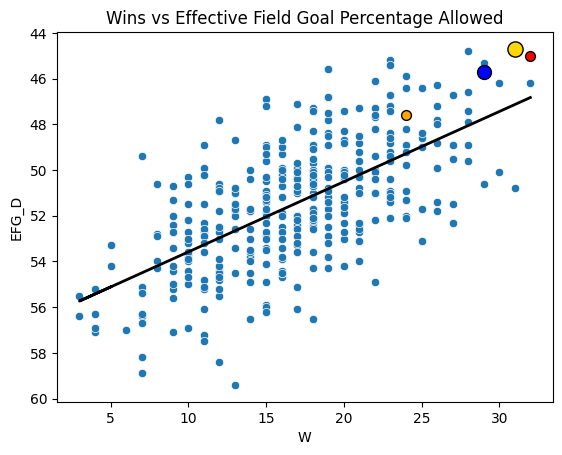

In [32]:
# Plot every team
sns.scatterplot(data=cbb26, x="W", y="EFG_D")
plt.title("Wins vs Effective Field Goal Percentage Allowed")

# Trendline
x = cbb26["W"]
y = cbb26["EFG_D"]

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='black', linewidth=2)

# Highlight Michigan
michigan = cbb26[cbb26["TEAM"] == "Michigan"]
plt.scatter(
    michigan["W"],
    michigan["EFG_D"],
    color="gold",
    edgecolors="black",
    s=120,
    zorder=10
)

# Highlight UConn
uconn = cbb26[cbb26["TEAM"] == "Connecticut"]
plt.scatter(
    uconn["W"],
    uconn["EFG_D"],
    color="blue",
    edgecolors="black",
    s=100,
    zorder=10
)

# Highlight Arizona
arizona = cbb26[cbb26["TEAM"] == "Arizona"]
plt.scatter(
    arizona["W"],
    arizona["EFG_D"],
    color="red",
    edgecolors="black",
    s=50,
    zorder=10
)

# Highlight Illinois
illinois = cbb26[cbb26["TEAM"] == "Illinois"]
plt.scatter(
    illinois["W"],
    illinois["EFG_D"],
    color="orange",
    edgecolors="black",
    s=50,
    zorder=10
)

plt.gca().invert_yaxis()

This scatterplot shows a negative relationship between wins and Effective Field Goal Percentage Allowed. Teams that allowed opponents to shoot less efficiently generally had more wins. The Final Four teams were all toward the better end of this statistic, showing that preventing efficient shooting was important to their success.

**What Team had the Best Effective Field Goal Percentage Allowed in a Power Conference in 2026?**

In [33]:
top_efgd = powercbb26.sort_values(by="EFG_D", ascending=True)
print("20 Best Effective Field Goal Percentage Allowed")
print(top_efgd[["SEED", "CONF", "W", "TEAM", "EFG_D"]].head(20))

20 Best Effective Field Goal Percentage Allowed
    SEED CONF   W            TEAM  EFG_D
1    1.0  B10  31        Michigan   44.7
2    1.0  B12  32         Arizona   45.0
21   4.0  B12  23          Kansas   45.2
13   3.0  ACC  29        Virginia   45.3
8    2.0   BE  29     Connecticut   45.7
0    1.0  ACC  32            Duke   46.2
3    1.0  SEC  26         Florida   46.3
4    2.0  B12  28         Houston   46.6
31   NaN  B12  18      Cincinnati   47.3
59   NaN   BE  21      Seton Hall   47.3
14   5.0   BE  28      St. John's   47.4
5    3.0  B10  24        Illinois   47.6
15   6.0  SEC  22       Tennessee   47.7
19   4.0  B10  26        Nebraska   47.8
26   6.0  ACC  24  North Carolina   48.2
61   NaN  B12  18   West Virginia   48.3
12   3.0  B10  25    Michigan St.   48.6
16   6.0  ACC  23      Louisville   48.8
30   7.0  SEC  21        Kentucky   48.8
9    5.0  SEC  26      Vanderbilt   48.8


This ranking shows the top 20 teams in a Power Conference at Effective Field Goal Percentage Allowed. The top eight teams were all seeded fourth or higher, showing a strong relationship between preventing efficient shooting and being a successful team. Cincinnati and Seton Hall were the main outliers because they had strong numbers but were not highly seeded.

**What Team had the Worst Effective Field Goal Percentage Allowed in a Power Conference in 2026?**

In [34]:
worst_efgd = powercbb26.sort_values(by="EFG_D", ascending=False)
print("10 Worst Effective Field Goal Percentage Allowed")
print(worst_efgd[["SEED", "CONF", "W", "TEAM", "EFG_D"]].head(10))

10 Worst Effective Field Goal Percentage Allowed
     SEED CONF   W          TEAM  EFG_D
140   NaN  B10  12      Penn St.   58.4
112   NaN  B10  12      Maryland   54.4
93    NaN   BE  15        Xavier   54.1
114   NaN  B12  10          Utah   53.9
40    NaN  SEC  17        Auburn   53.6
102   NaN  ACC  13    Pittsburgh   53.4
116   NaN  B10  14       Rutgers   53.0
37   11.0  ACC  20    N.C. State   53.0
75    NaN  B12  17      Colorado   52.9
74    NaN  B12  19  Oklahoma St.   52.9


This ranking shows the 10 worst teams in a Power Conference at Effective Field Goal Percentage Allowed. Most of these teams did not make the NCAA Tournament and had relatively low win totals. This shows that allowing opponents to shoot efficiently can make it much harder for a team to be successful.

**Turnover Rate:**

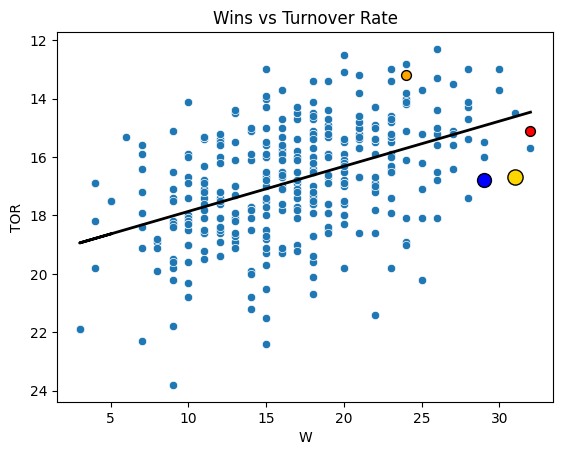

In [35]:
# Plot every team
sns.scatterplot(data=cbb26, x="W", y="TOR")
plt.title("Wins vs Turnover Rate")

# Trendline
x = cbb26["W"]
y = cbb26["TOR"]

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='black', linewidth=2)

# Highlight Michigan
michigan = cbb26[cbb26["TEAM"] == "Michigan"]
plt.scatter(
    michigan["W"],
    michigan["TOR"],
    color="gold",
    edgecolors="black",
    s=120,
    zorder=10
)

# Highlight UConn
uconn = cbb26[cbb26["TEAM"] == "Connecticut"]
plt.scatter(
    uconn["W"],
    uconn["TOR"],
    color="blue",
    edgecolors="black",
    s=100,
    zorder=10
)

# Highlight Arizona
arizona = cbb26[cbb26["TEAM"] == "Arizona"]
plt.scatter(
    arizona["W"],
    arizona["TOR"],
    color="red",
    edgecolors="black",
    s=50,
    zorder=10
)

# Highlight Illinois
illinois = cbb26[cbb26["TEAM"] == "Illinois"]
plt.scatter(
    illinois["W"],
    illinois["TOR"],
    color="orange",
    edgecolors="black",
    s=50,
    zorder=10
)

plt.gca().invert_yaxis()

This scatterplot shows a negative relationship between wins and Turnover Rate. Teams that turned the ball over less frequently generally had more wins. However, there is still a good amount of variation in the graph, showing that taking care of the ball is important but is not the only factor that determines success.

**What Team had the Best Turnover Rate in a Power Conference in 2026?**

In [36]:
top_tor = powercbb26.sort_values(by="TOR", ascending=True)
print("20 Best Turnover Rate")
print(top_tor[["SEED", "CONF", "W", "TEAM", "TOR"]].head(20))

20 Best Turnover Rate
    SEED CONF   W            TEAM   TOR
18   4.0  SEC  26        Arkansas  12.3
20   5.0  B10  24       Wisconsin  12.8
4    2.0  B12  28         Houston  13.0
17   4.0  SEC  23         Alabama  13.0
62   NaN  B10  15    Northwestern  13.0
37  11.0  ACC  20      N.C. State  13.1
5    3.0  B10  24        Illinois  13.2
9    5.0  SEC  26      Vanderbilt  13.3
23   7.0  B10  23            UCLA  13.4
7    2.0  B10  27          Purdue  13.5
93   NaN   BE  15          Xavier  13.9
26   6.0  ACC  24  North Carolina  14.0
63   NaN  SEC  15     Mississippi  14.0
29   8.0  ACC  24         Clemson  14.2
36   8.0  SEC  22         Georgia  14.3
19   4.0  B10  26        Nebraska  14.4
38   NaN  SEC  19        Oklahoma  14.4
75   NaN  B12  17        Colorado  14.5
99   NaN  SEC  13  South Carolina  14.5
39  10.0  SEC  21       Texas A&M  14.6


This ranking shows the 20 teams with the best Turnover Rate in a Power Conference. Many of the teams near the top were successful teams, including Arkansas, Houston, Alabama, Illinois, and Purdue. This suggests that taking care of the ball can be an important part of winning, although it is not enough by itself.

**What Team had the Worst Turnover Rate in a Power Conference in 2026?**

In [37]:
worst_tor = powercbb26.sort_values(by="TOR", ascending=False)
print("10 Worst Turnover Rate")
print(worst_tor[["SEED", "CONF", "W", "TEAM", "TOR"]].head(10))

10 Worst Turnover Rate
     SEED CONF   W           TEAM   TOR
161   NaN  ACC  11   Georgia Tech  18.6
112   NaN  B10  12       Maryland  18.6
45   10.0  SEC  20       Missouri  18.0
100   NaN   BE  16         DePaul  17.8
89    NaN  B10  12         Oregon  17.6
61    NaN  B12  18  West Virginia  17.5
65    NaN  B10  18            USC  17.4
101   NaN  B12  12     Kansas St.  17.4
102   NaN  ACC  13     Pittsburgh  17.3
12    3.0  B10  25   Michigan St.  17.1


This ranking shows the 10 teams with the worst Turnover Rate in a Power Conference. Most of these teams were not highly seeded, although Missouri and Michigan State were exceptions. This suggests that teams that turn the ball over frequently generally have a harder time winning consistently.

**Turnover Rate Allowed:**

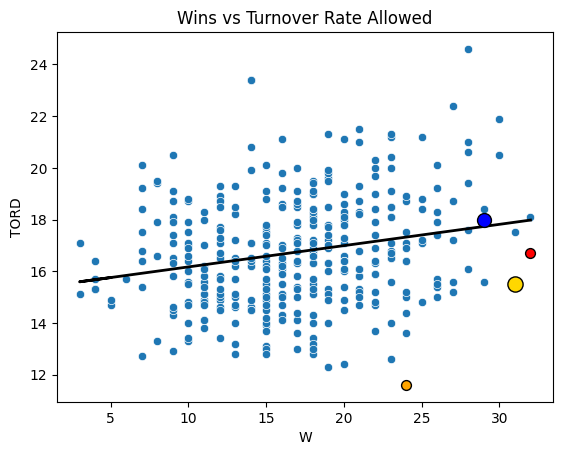

In [38]:
# Plot every team
sns.scatterplot(data=cbb26, x="W", y="TORD")
plt.title("Wins vs Turnover Rate Allowed")

# Trendline
x = cbb26["W"]
y = cbb26["TORD"]

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='black', linewidth=2)

# Highlight Michigan
michigan = cbb26[cbb26["TEAM"] == "Michigan"]
plt.scatter(
    michigan["W"],
    michigan["TORD"],
    color="gold",
    edgecolors="black",
    s=120,
    zorder=10
)

# Highlight UConn
uconn = cbb26[cbb26["TEAM"] == "Connecticut"]
plt.scatter(
    uconn["W"],
    uconn["TORD"],
    color="blue",
    edgecolors="black",
    s=100,
    zorder=10
)

# Highlight Arizona
arizona = cbb26[cbb26["TEAM"] == "Arizona"]
plt.scatter(
    arizona["W"],
    arizona["TORD"],
    color="red",
    edgecolors="black",
    s=50,
    zorder=10
)

# Highlight Illinois
illinois = cbb26[cbb26["TEAM"] == "Illinois"]
plt.scatter(
    illinois["W"],
    illinois["TORD"],
    color="orange",
    edgecolors="black",
    s=50,
    zorder=10
)

This scatterplot shows a positive relationship between wins and Turnover Rate Allowed. Teams that forced opponents into more turnovers generally had more wins. However, the relationship is not extremely strong, showing that forcing turnovers alone does not guarantee a successful season.

**What Team had the Best Turnover Rate Allowed in a Power Conference in 2026?**

In [39]:
top_tord = powercbb26.sort_values(by="TORD", ascending=False)
print("20 Best Turnover Rate Allowed")
print(top_tord[["SEED", "CONF", "W", "TEAM", "TORD"]].head(20))

20 Best Turnover Rate Allowed
     SEED CONF   W           TEAM  TORD
6     2.0  B12  27       Iowa St.  22.4
59    NaN   BE  21     Seton Hall  21.5
4     2.0  B12  28        Houston  21.0
25    9.0  B10  21           Iowa  21.0
48    9.0  B12  22            TCU  19.7
14    5.0   BE  28     St. John's  19.4
76    NaN   BE  12      Marquette  19.3
19    4.0  B10  26       Nebraska  19.2
50    NaN  ACC  18    Florida St.  19.0
35    8.0   BE  24      Villanova  18.7
100   NaN   BE  16         DePaul  18.6
60    NaN  B12  17    Arizona St.  18.5
36    8.0  SEC  22        Georgia  18.4
34    7.0  ACC  25       Miami FL  18.4
58    NaN  ACC  20       Stanford  18.3
39   10.0  SEC  21      Texas A&M  18.3
37   11.0  ACC  20     N.C. State  18.2
31    NaN  B12  18     Cincinnati  18.2
0     1.0  ACC  32           Duke  18.1
61    NaN  B12  18  West Virginia  18.1


This ranking shows the 20 teams with the best Turnover Rate Allowed in a Power Conference. Several successful teams appear near the top, including Iowa State, Houston, and Nebraska, but there are also several teams with lower win totals. This suggests that forcing turnovers can help a team, but it does not have as strong of a relationship with wins as some of the other statistics.

**What Team had the Worst Turnover Rate Allowed in a Power Conference in 2026?**

In [40]:
worst_tord = powercbb26.sort_values(by="TORD", ascending=True)
print("10 Worst Offensive Turnover Rate")
print(worst_tor[["SEED", "CONF", "W", "TEAM", "TORD"]].head(10))

10 Worst Offensive Turnover Rate
     SEED CONF   W           TEAM  TORD
161   NaN  ACC  11   Georgia Tech  15.6
112   NaN  B10  12       Maryland  14.9
45   10.0  SEC  20       Missouri  16.6
100   NaN   BE  16         DePaul  18.6
89    NaN  B10  12         Oregon  15.7
61    NaN  B12  18  West Virginia  18.1
65    NaN  B10  18            USC  16.3
101   NaN  B12  12     Kansas St.  17.1
102   NaN  ACC  13     Pittsburgh  16.2
12    3.0  B10  25   Michigan St.  14.8


This ranking shows the 10 teams with the worst Turnover Rate Allowed in a Power Conference. Most of these teams were not highly seeded, with several having fewer than 20 wins. This suggests that struggling to force turnovers can hurt a team, although the relationship is not extremely strong.

**Offensive Rebounds:**

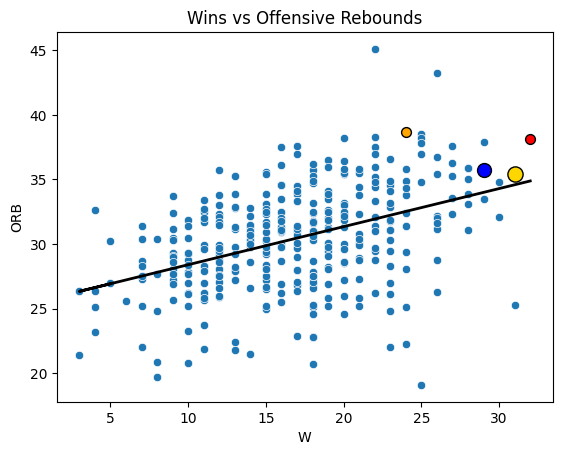

In [41]:
# Plot every team
sns.scatterplot(data=cbb26, x="W", y="ORB")
plt.title("Wins vs Offensive Rebounds")

# Trendline
x = cbb26["W"]
y = cbb26["ORB"]

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='black', linewidth=2)

# Highlight Michigan
michigan = cbb26[cbb26["TEAM"] == "Michigan"]
plt.scatter(
    michigan["W"],
    michigan["ORB"],
    color="gold",
    edgecolors="black",
    s=120,
    zorder=10
)

# Highlight UConn
uconn = cbb26[cbb26["TEAM"] == "Connecticut"]
plt.scatter(
    uconn["W"],
    uconn["ORB"],
    color="blue",
    edgecolors="black",
    s=100,
    zorder=10
)

# Highlight Arizona
arizona = cbb26[cbb26["TEAM"] == "Arizona"]
plt.scatter(
    arizona["W"],
    arizona["ORB"],
    color="red",
    edgecolors="black",
    s=50,
    zorder=10
)

# Highlight Illinois
illinois = cbb26[cbb26["TEAM"] == "Illinois"]
plt.scatter(
    illinois["W"],
    illinois["ORB"],
    color="orange",
    edgecolors="black",
    s=50,
    zorder=10
)

This scatterplot shows a positive relationship between wins and Offensive Rebounding. Teams that collected more offensive rebounds generally had more wins. However, there is a lot of variation in the graph, showing that offensive rebounding is helpful but is not one of the only factors that leads to winning.

**What Team was the Best at Offensive Rebounding in a Power Conference in 2026?**

In [42]:
top_orb = powercbb26.sort_values(by="ORB", ascending=False)
print("20 Best Offensive Rebounds")
print(top_orb[["SEED", "CONF", "W", "TEAM", "ORB"]].head(20))

20 Best Offensive Rebounds
    SEED CONF   W          TEAM   ORB
15   6.0  SEC  22     Tennessee  45.1
3    1.0  SEC  26       Florida  43.2
5    3.0  B10  24      Illinois  38.7
12   3.0  B10  25  Michigan St.  38.5
0    1.0  ACC  32          Duke  38.1
2    1.0  B12  32       Arizona  38.1
13   3.0  ACC  29      Virginia  37.9
40   NaN  SEC  17        Auburn  37.6
46   NaN  B12  16        Baylor  37.5
34   7.0  ACC  25      Miami FL  37.0
7    2.0  B10  27        Purdue  36.3
4    2.0  B12  28       Houston  35.9
14   5.0   BE  28    St. John's  35.9
44  11.0  SEC  18         Texas  35.7
8    2.0   BE  29   Connecticut  35.7
59   NaN   BE  21    Seton Hall  35.6
45  10.0  SEC  20      Missouri  35.5
41  11.0  ACC  20           SMU  35.4
1    1.0  B10  31      Michigan  35.4
6    2.0  B12  27      Iowa St.  35.3


This ranking shows the 20 best teams in a Power Conference at Offensive Rebounding. Several highly successful teams appear near the top, including Florida, Duke, Arizona, Illinois, and Michigan State. This shows that offensive rebounding can help successful teams create additional opportunities, although there are also several lower-win teams in the ranking.

**What Team was the Worst at Offensive Rebounding in a Power Conference in 2026?**

In [43]:
worst_orb = powercbb26.sort_values(by="ORB", ascending=True)
print("10 Worst Offensive Rebounds")
print(worst_orb[["SEED", "CONF", "W", "TEAM", "ORB"]].head(10))

10 Worst Offensive Rebounds
     SEED CONF   W            TEAM   ORB
67    NaN  ACC  21      California  25.8
140   NaN  B10  12        Penn St.  25.9
19    4.0  B10  26        Nebraska  26.3
93    NaN   BE  15          Xavier  26.5
33    NaN  B10  18         Indiana  26.9
99    NaN  SEC  13  South Carolina  27.2
56    NaN  B10  15       Minnesota  27.2
84    NaN   BE  15       Creighton  27.5
29    8.0  ACC  24         Clemson  28.1
62    NaN  B10  15    Northwestern  28.1


This ranking shows the 10 worst teams in a Power Conference at Offensive Rebounding. Most of these teams were not highly seeded, although Nebraska and Clemson were exceptions. This suggests that offensive rebounding can contribute to winning, but it is not one of the strongest factors by itself.

**Defensive Rebounds:**

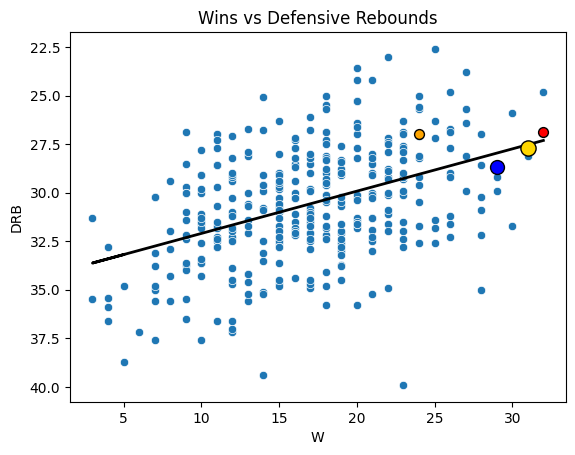

In [44]:
# Plot every team
sns.scatterplot(data=cbb26, x="W", y="DRB")
plt.title("Wins vs Defensive Rebounds")

# Trendline
x = cbb26["W"]
y = cbb26["DRB"]

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='black', linewidth=2)

# Highlight Michigan
michigan = cbb26[cbb26["TEAM"] == "Michigan"]
plt.scatter(
    michigan["W"],
    michigan["DRB"],
    color="gold",
    edgecolors="black",
    s=120,
    zorder=10
)

# Highlight UConn
uconn = cbb26[cbb26["TEAM"] == "Connecticut"]
plt.scatter(
    uconn["W"],
    uconn["DRB"],
    color="blue",
    edgecolors="black",
    s=100,
    zorder=10
)

# Highlight Arizona
arizona = cbb26[cbb26["TEAM"] == "Arizona"]
plt.scatter(
    arizona["W"],
    arizona["DRB"],
    color="red",
    edgecolors="black",
    s=50,
    zorder=10
)

# Highlight Illinois
illinois = cbb26[cbb26["TEAM"] == "Illinois"]
plt.scatter(
    illinois["W"],
    illinois["DRB"],
    color="orange",
    edgecolors="black",
    s=50,
    zorder=10
)

plt.gca().invert_yaxis()

This scatterplot shows a positive relationship between wins and Defensive Rebounding. Teams with more defensive rebounds generally had more wins, although there are several outliers. This shows that defensive rebounding can contribute to winning but does not guarantee success by itself.

**What Team was the Best at Defensive Rebounds in a Power Conference in 2026?**

In [45]:
top_drb = powercbb26.sort_values(by="DRB", ascending=False)
print("20 Best Defensive Rebounds")
print(top_drb[["SEED", "CONF", "W", "TEAM", "DRB"]].head(20))

20 Best Defensive Rebounds
     SEED CONF   W            TEAM   DRB
36    8.0  SEC  22         Georgia  34.9
60    NaN  B12  17     Arizona St.  34.9
62    NaN  B10  15    Northwestern  34.7
76    NaN   BE  12       Marquette  34.7
50    NaN  ACC  18     Florida St.  34.1
101   NaN  B12  12      Kansas St.  33.9
80    NaN  ACC  15        Syracuse  33.6
116   NaN  B10  14         Rutgers  33.1
38    NaN  SEC  19        Oklahoma  33.0
66    NaN  ACC  17     Wake Forest  32.9
17    4.0  SEC  23         Alabama  32.8
63    NaN  SEC  15     Mississippi  32.6
52    NaN  ACC  19   Virginia Tech  32.6
39   10.0  SEC  21       Texas A&M  32.5
23    7.0  B10  23            UCLA  32.4
89    NaN  B10  12          Oregon  32.3
65    NaN  B10  18             USC  32.2
46    NaN  B12  16          Baylor  32.2
40    NaN  SEC  17          Auburn  32.1
99    NaN  SEC  13  South Carolina  32.1


This ranking shows the 20 best teams in a Power Conference at Defensive Rebounding. There are several teams with lower win totals in the top 20, showing that defensive rebounding by itself does not guarantee success. Overall, this statistic appears to have a weaker relationship with wins than offensive and defensive efficiency.

**What Team was the Worst at Defensive Rebounds in a Power Conference in 2026?**

In [46]:
worst_drb = powercbb26.sort_values(by="DRB", ascending=True)
print("10 Worst Defensive Rebounds")
print(worst_drb[["SEED", "CONF", "W", "TEAM", "DRB"]].head(10))

10 Worst Defensive Rebounds
    SEED CONF   W          TEAM   DRB
12   3.0  B10  25  Michigan St.  22.6
0    1.0  ACC  32          Duke  24.8
3    1.0  SEC  26       Florida  24.8
29   8.0  ACC  24       Clemson  25.7
34   7.0  ACC  25      Miami FL  26.3
7    2.0  B10  27        Purdue  26.4
96   NaN  ACC  13    Notre Dame  26.7
16   6.0  ACC  23    Louisville  26.9
44  11.0  SEC  18         Texas  26.9
2    1.0  B12  32       Arizona  26.9


This ranking shows the 10 worst teams in a Power Conference at Defensive Rebounding. Interestingly, several highly successful teams, including Duke, Florida, Purdue, and Arizona, appear in the bottom 10. This shows that defensive rebounding alone does not determine how successful a team will be.

**Free Throw Rate:**

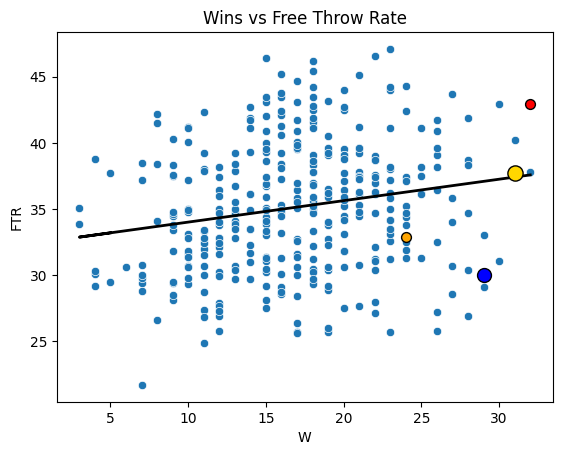

In [47]:
# Plot every team
sns.scatterplot(data=cbb26, x="W", y="FTR")
plt.title("Wins vs Free Throw Rate")

# Trendline
x = cbb26["W"]
y = cbb26["FTR"]

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='black', linewidth=2)

# Highlight Michigan
michigan = cbb26[cbb26["TEAM"] == "Michigan"]
plt.scatter(
    michigan["W"],
    michigan["FTR"],
    color="gold",
    edgecolors="black",
    s=120,
    zorder=10
)

# Highlight UConn
uconn = cbb26[cbb26["TEAM"] == "Connecticut"]
plt.scatter(
    uconn["W"],
    uconn["FTR"],
    color="blue",
    edgecolors="black",
    s=100,
    zorder=10
)

# Highlight Arizona
arizona = cbb26[cbb26["TEAM"] == "Arizona"]
plt.scatter(
    arizona["W"],
    arizona["FTR"],
    color="red",
    edgecolors="black",
    s=50,
    zorder=10
)

# Highlight Illinois
illinois = cbb26[cbb26["TEAM"] == "Illinois"]
plt.scatter(
    illinois["W"],
    illinois["FTR"],
    color="orange",
    edgecolors="black",
    s=50,
    zorder=10
)

This scatterplot shows a positive relationship between wins and Free Throw Rate. Teams that got to the free throw line more frequently generally had more wins. However, the relationship is not extremely strong, showing that getting to the free throw line is only one part of having a successful offense.

**What Team had the Best Free Throw Rate in a Power Conference in 2026?**

In [48]:
top_ftr = powercbb26.sort_values(by="FTR", ascending=False)
print("20 Best Free Throw Rate")
print(top_ftr[["SEED", "CONF", "W", "TEAM", "FTR"]].head(20))

20 Best Free Throw Rate
    SEED CONF   W          TEAM   FTR
44  11.0  SEC  18         Texas  46.2
40   NaN  SEC  17        Auburn  44.7
65   NaN  B10  18           USC  44.2
2    1.0  B12  32       Arizona  42.9
45  10.0  SEC  20      Missouri  42.5
71   NaN   BE  16        Butler  42.1
14   5.0   BE  28    St. John's  41.9
69   NaN  SEC  15           LSU  40.9
60   NaN  B12  17   Arizona St.  39.5
74   NaN  B12  19  Oklahoma St.  39.4
3    1.0  SEC  26       Florida  39.1
15   6.0  SEC  22     Tennessee  38.7
48   9.0  B12  22           TCU  38.7
9    5.0  SEC  26    Vanderbilt  38.2
0    1.0  ACC  32          Duke  37.8
22   8.0  B10  21      Ohio St.  37.8
1    1.0  B10  31      Michigan  37.7
34   7.0  ACC  25      Miami FL  37.5
30   7.0  SEC  21      Kentucky  37.5
39  10.0  SEC  21     Texas A&M  37.4


This ranking shows the 20 best teams in a Power Conference at Free Throw Rate. There are several successful teams in the top 20, including Arizona, Florida, Duke, and Michigan, but there are also several teams with lower win totals. This suggests that getting to the free throw line can help a team, but it is not one of the strongest factors connected to wins.

**What Team had the Worst Free Throw Rate in a Power Conference in 2026?**

In [49]:
worst_ftr = powercbb26.sort_values(by="FTR", ascending=True)
print("10 Worst Free Throw Rate")
print(worst_ftr[["SEED", "CONF", "W", "TEAM", "FTR"]].head(10))

10 Worst Free Throw Rate
     SEED CONF   W         TEAM   FTR
4     2.0  B12  28      Houston  26.9
101   NaN  B12  12   Kansas St.  26.9
11    5.0  B12  22   Texas Tech  27.1
19    4.0  B10  26     Nebraska  27.2
84    NaN   BE  15    Creighton  27.5
93    NaN   BE  15       Xavier  28.1
7     2.0  B10  27       Purdue  28.6
31    NaN  B12  18   Cincinnati  29.4
8     2.0   BE  29  Connecticut  30.0
51    NaN  B10  16   Washington  30.1


This ranking shows the 10 worst teams in a Power Conference at Free Throw Rate. Several highly successful teams, including Houston, Purdue, Nebraska, and Connecticut, appear in the bottom 10. This shows that teams can still be successful without getting to the free throw line frequently.

**Free Throw Rate Allowed:**

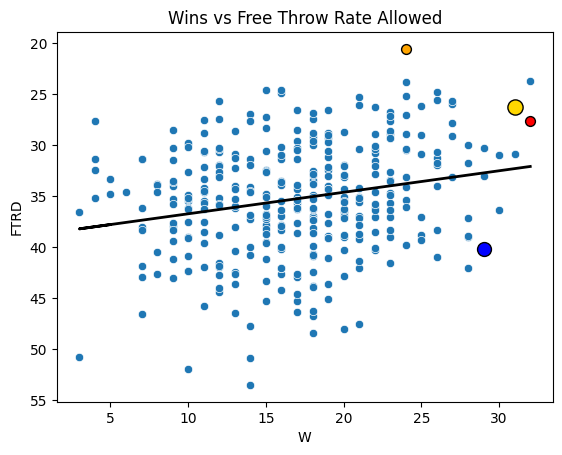

In [50]:
# Plot every team
sns.scatterplot(data=cbb26, x="W", y="FTRD")
plt.title("Wins vs Free Throw Rate Allowed")

# Trendline
x = cbb26["W"]
y = cbb26["FTRD"]

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='black', linewidth=2)

# Highlight Michigan
michigan = cbb26[cbb26["TEAM"] == "Michigan"]
plt.scatter(
    michigan["W"],
    michigan["FTRD"],
    color="gold",
    edgecolors="black",
    s=120,
    zorder=10
)

# Highlight UConn
uconn = cbb26[cbb26["TEAM"] == "Connecticut"]
plt.scatter(
    uconn["W"],
    uconn["FTRD"],
    color="blue",
    edgecolors="black",
    s=100,
    zorder=10
)

# Highlight Arizona
arizona = cbb26[cbb26["TEAM"] == "Arizona"]
plt.scatter(
    arizona["W"],
    arizona["FTRD"],
    color="red",
    edgecolors="black",
    s=50,
    zorder=10
)

# Highlight Illinois
illinois = cbb26[cbb26["TEAM"] == "Illinois"]
plt.scatter(
    illinois["W"],
    illinois["FTRD"],
    color="orange",
    edgecolors="black",
    s=50,
    zorder=10
)

plt.gca().invert_yaxis()

This scatterplot shows a negative relationship between wins and Free Throw Rate Allowed. Teams that allowed opponents to get to the free throw line less frequently generally had more wins. This suggests that limiting easy scoring opportunities can contribute to a team's success.

**What Team had the Best Free Throw Rate Allowed in a Power Conference in 2026?**

In [51]:
top_ftrd = powercbb26.sort_values(by="FTRD", ascending=True)
print("20 Best Free Throw Rate Allowed")
print(top_ftrd[["SEED", "CONF", "W", "TEAM", "FTRD"]].head(20))

20 Best Free Throw Rate Allowed
     SEED CONF   W            TEAM  FTRD
5     3.0  B10  24        Illinois  20.6
0     1.0  ACC  32            Duke  23.7
26    6.0  ACC  24  North Carolina  23.8
84    NaN   BE  15       Creighton  24.6
19    4.0  B10  26        Nebraska  24.8
71    NaN   BE  16          Butler  24.9
7     2.0  B10  27          Purdue  26.0
1     1.0  B10  31        Michigan  26.3
56    NaN  B10  15       Minnesota  27.3
140   NaN  B10  12        Penn St.  27.5
2     1.0  B12  32         Arizona  27.7
21    4.0  B12  23          Kansas  27.7
6     2.0  B12  27        Iowa St.  27.9
52    NaN  ACC  19   Virginia Tech  28.8
35    8.0   BE  24       Villanova  28.9
32    6.0  B12  23             BYU  28.9
34    7.0  ACC  25        Miami FL  29.0
61    NaN  B12  18   West Virginia  29.2
114   NaN  B12  10            Utah  29.9
31    NaN  B12  18      Cincinnati  30.0


This ranking shows the 20 teams that allowed the lowest Free Throw Rate in a Power Conference. Several highly successful teams, including Duke, Illinois, Michigan, Purdue, and Arizona, appear near the top. This suggests that limiting opponents' opportunities at the free throw line can be helpful for winning.

**What Team had the Worst Free Throw Rate Allowed in a Power Conference in 2026?**

In [52]:
worst_ftrd = powercbb26.sort_values(by="FTRD", ascending=False)
print("10 Worst Free Throw Rate Allowed")
print(worst_ftrd[["SEED", "CONF", "W", "TEAM", "FTRD"]].head(10))

10 Worst Free Throw Rate Allowed
     SEED CONF   W         TEAM  FTRD
59    NaN   BE  21   Seton Hall  42.1
63    NaN  SEC  15  Mississippi  41.2
9     5.0  SEC  26   Vanderbilt  41.0
44   11.0  SEC  18        Texas  40.7
58    NaN  ACC  20     Stanford  40.3
8     2.0   BE  29  Connecticut  40.2
25    9.0  B10  21         Iowa  39.1
4     2.0  B12  28      Houston  39.0
69    NaN  SEC  15          LSU  37.8
100   NaN   BE  16       DePaul  37.8


This ranking shows the 10 teams that allowed the highest Free Throw Rate in a Power Conference. There are several successful teams in this group, including Connecticut and Vanderbilt. This shows that allowing opponents to get to the free throw line frequently does not automatically prevent a team from having a successful season.

**2 point Field Goal Percentage:**

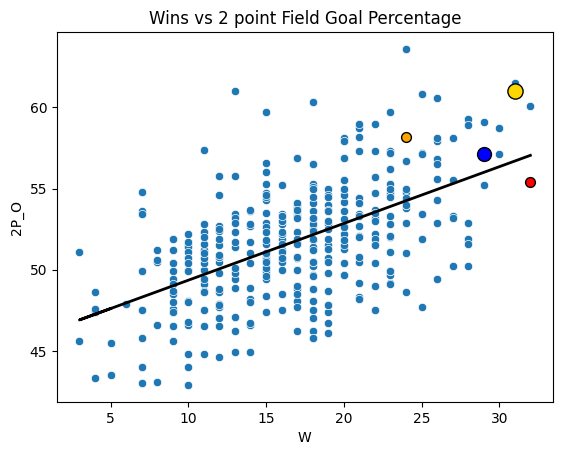

In [53]:
# Plot every team
sns.scatterplot(data=cbb26, x="W", y="2P_O")
plt.title("Wins vs 2 point Field Goal Percentage")

# Trendline
x = cbb26["W"]
y = cbb26["2P_O"]

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='black', linewidth=2)

# Highlight Michigan
michigan = cbb26[cbb26["TEAM"] == "Michigan"]
plt.scatter(
    michigan["W"],
    michigan["2P_O"],
    color="gold",
    edgecolors="black",
    s=120,
    zorder=10
)

# Highlight UConn
uconn = cbb26[cbb26["TEAM"] == "Connecticut"]
plt.scatter(
    uconn["W"],
    uconn["2P_O"],
    color="blue",
    edgecolors="black",
    s=100,
    zorder=10
)

# Highlight Arizona
arizona = cbb26[cbb26["TEAM"] == "Arizona"]
plt.scatter(
    arizona["W"],
    arizona["2P_O"],
    color="red",
    edgecolors="black",
    s=50,
    zorder=10
)

# Highlight Illinois
illinois = cbb26[cbb26["TEAM"] == "Illinois"]
plt.scatter(
    illinois["W"],
    illinois["2P_O"],
    color="orange",
    edgecolors="black",
    s=50,
    zorder=10
)

This scatterplot shows a positive relationship between wins and 2-point Field Goal Percentage. Teams that shot a higher percentage from inside the 3-point line generally won more games. The Final Four teams were all toward the higher end, showing that efficient 2-point shooting was an important part of their success.

**What Team had the Best 2 point Field Goal Percentage in a Power Conference in 2026?**

In [54]:
top_2po = powercbb26.sort_values(by="2P_O", ascending=False)
print("20 Best 2 point Field Goal Percentage")
print(top_2po[["SEED", "CONF", "W", "TEAM", "2P_O"]].head(20))

20 Best 2 point Field Goal Percentage
     SEED CONF   W            TEAM  2P_O
1     1.0  B10  31        Michigan  61.0
33    NaN  B10  18         Indiana  60.3
0     1.0  ACC  32            Duke  60.1
16    6.0  ACC  23      Louisville  59.7
25    9.0  B10  21            Iowa  58.7
22    8.0  B10  21        Ohio St.  58.2
5     3.0  B10  24        Illinois  58.2
7     2.0  B10  27          Purdue  58.1
19    4.0  B10  26        Nebraska  58.1
3     1.0  SEC  26         Florida  57.9
17    4.0  SEC  23         Alabama  57.3
36    8.0  SEC  22         Georgia  57.3
34    7.0  ACC  25        Miami FL  57.2
8     2.0   BE  29     Connecticut  57.1
45   10.0  SEC  20        Missouri  56.9
9     5.0  SEC  26      Vanderbilt  56.8
26    6.0  ACC  24  North Carolina  56.7
32    6.0  B12  23             BYU  56.2
56    NaN  B10  15       Minnesota  56.0
140   NaN  B10  12        Penn St.  55.8


This ranking shows the 20 teams with the best 2-point Field Goal Percentage in a Power Conference. Most of the teams in the top 20 were highly successful, including Michigan, Duke, Florida, Purdue, and Connecticut. This shows that being efficient from inside the 3-point line is an important part of having a successful offense.

**What Team had the Worst 2 point Field Goal Percentage in a Power Conference in 2026?**

In [55]:
worst_2po = powercbb26.sort_values(by="2P_O", ascending=True)
print("10 Worst 2 point Field Goal Percentage")
print(worst_2po[["SEED", "CONF", "W", "TEAM", "2P_O"]].head(10))

10 Worst 2 point Field Goal Percentage
     SEED CONF   W            TEAM  2P_O
116   NaN  B10  14         Rutgers  46.6
59    NaN   BE  21      Seton Hall  48.3
112   NaN  B10  12        Maryland  48.6
161   NaN  ACC  11    Georgia Tech  48.7
138   NaN  ACC  11  Boston College  49.1
93    NaN   BE  15          Xavier  49.8
31    NaN  B12  18      Cincinnati  50.2
58    NaN  ACC  20        Stanford  50.4
89    NaN  B10  12          Oregon  50.5
100   NaN   BE  16          DePaul  50.5


This ranking shows the 10 teams with the worst 2-point Field Goal Percentage in a Power Conference. Most of these teams were not highly successful, although Seton Hall and Stanford were exceptions. This suggests that poor 2-point shooting can make it more difficult to win consistently.

**2 point Field Goal Percentage Allowed:**

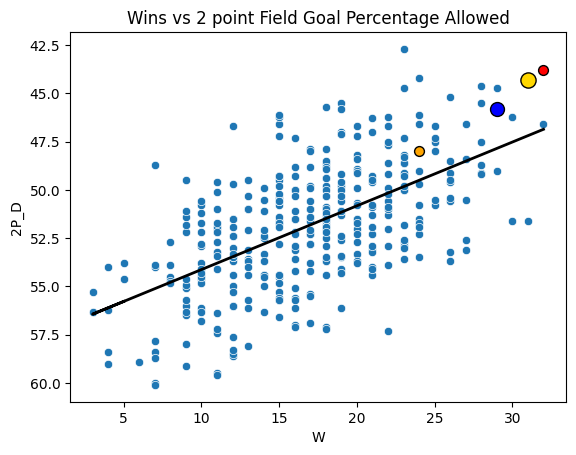

In [56]:
# Plot every team
sns.scatterplot(data=cbb26, x="W", y="2P_D")
plt.title("Wins vs 2 point Field Goal Percentage Allowed")

# Trendline
x = cbb26["W"]
y = cbb26["2P_D"]

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='black', linewidth=2)

# Highlight Michigan
michigan = cbb26[cbb26["TEAM"] == "Michigan"]
plt.scatter(
    michigan["W"],
    michigan["2P_D"],
    color="gold",
    edgecolors="black",
    s=120,
    zorder=10
)

# Highlight UConn
uconn = cbb26[cbb26["TEAM"] == "Connecticut"]
plt.scatter(
    uconn["W"],
    uconn["2P_D"],
    color="blue",
    edgecolors="black",
    s=100,
    zorder=10
)

# Highlight Arizona
arizona = cbb26[cbb26["TEAM"] == "Arizona"]
plt.scatter(
    arizona["W"],
    arizona["2P_D"],
    color="red",
    edgecolors="black",
    s=50,
    zorder=10
)

# Highlight Illinois
illinois = cbb26[cbb26["TEAM"] == "Illinois"]
plt.scatter(
    illinois["W"],
    illinois["2P_D"],
    color="orange",
    edgecolors="black",
    s=50,
    zorder=10
)

plt.gca().invert_yaxis()

This scatterplot shows a negative relationship between wins and 2-point Field Goal Percentage Allowed. Teams that prevented opponents from shooting efficiently on 2-point shots generally had more wins. This shows that interior defense was an important part of having a successful team.

**What Team had the Best 2 point Field Goal Percentage Allowed in a Power Conference in 2026?**

In [57]:
top_2pd = powercbb26.sort_values(by="2P_D", ascending=True)
print("20 Best 2 point Field Goal Percentage Allowed")
print(top_2pd[["SEED", "CONF", "W", "TEAM", "2P_D"]].head(20))

20 Best 2 point Field Goal Percentage Allowed
     SEED CONF   W            TEAM  2P_D
2     1.0  B12  32         Arizona  43.8
1     1.0  B10  31        Michigan  44.3
13    3.0  ACC  29        Virginia  44.7
21    4.0  B12  23          Kansas  44.7
3     1.0  SEC  26         Florida  45.2
4     2.0  B12  28         Houston  45.5
61    NaN  B12  18   West Virginia  45.7
8     2.0   BE  29     Connecticut  45.8
26    6.0  ACC  24  North Carolina  46.1
59    NaN   BE  21      Seton Hall  46.3
0     1.0  ACC  32            Duke  46.6
100   NaN   BE  16          DePaul  47.3
14    5.0   BE  28      St. John's  47.5
31    NaN  B12  18      Cincinnati  47.9
12    3.0  B10  25    Michigan St.  48.0
5     3.0  B10  24        Illinois  48.0
16    6.0  ACC  23      Louisville  48.6
33    NaN  B10  18         Indiana  48.6
17    4.0  SEC  23         Alabama  48.6
45   10.0  SEC  20        Missouri  48.9


This ranking shows the 20 teams that allowed the lowest 2-point Field Goal Percentage in a Power Conference. Six of the top eight teams were seeded fourth or higher, including Arizona, Michigan, Virginia, and Florida. This shows that preventing opponents from scoring efficiently inside was an important part of many successful teams.

**What Team had the Worst 2 point Field Goal Percentage Allowed in a Power Conference in 2026?**

In [58]:
worst_2pd = powercbb26.sort_values(by="2P_D", ascending=False)
print("10 Worst 2 point Field Goal Percentage Allowed")
print(worst_2pd[["SEED", "CONF", "W", "TEAM", "2P_D"]].head(10))

10 Worst 2 point Field Goal Percentage Allowed
     SEED CONF   W            TEAM  2P_D
140   NaN  B10  12        Penn St.  58.6
93    NaN   BE  15          Xavier  55.3
114   NaN  B12  10            Utah  54.6
112   NaN  B10  12        Maryland  54.4
66    NaN  ACC  17     Wake Forest  54.2
52    NaN  ACC  19   Virginia Tech  54.1
25    9.0  B10  21            Iowa  54.0
18    4.0  SEC  26        Arkansas  53.7
101   NaN  B12  12      Kansas St.  53.7
99    NaN  SEC  13  South Carolina  53.7


This ranking shows the 10 teams that allowed the highest 2-point Field Goal Percentage in a Power Conference. Most of these teams were not highly seeded, although Iowa and Arkansas were exceptions. This suggests that allowing opponents to shoot efficiently inside can make winning more difficult.

**3 point Field Goal Percentage:**

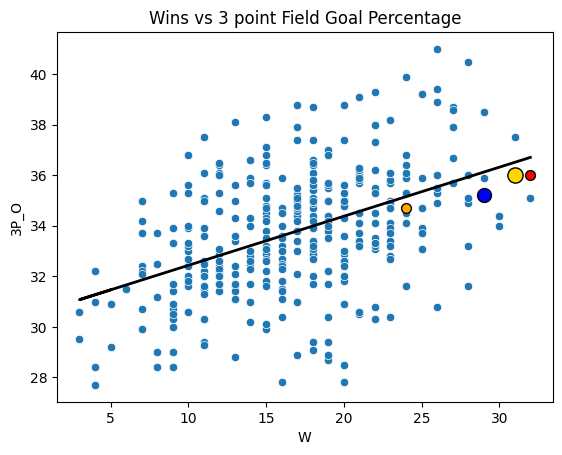

In [59]:
# Plot every team
sns.scatterplot(data=cbb26, x="W", y="3P_O")
plt.title("Wins vs 3 point Field Goal Percentage")

# Trendline
x = cbb26["W"]
y = cbb26["3P_O"]

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='black', linewidth=2)

# Highlight Michigan
michigan = cbb26[cbb26["TEAM"] == "Michigan"]
plt.scatter(
    michigan["W"],
    michigan["3P_O"],
    color="gold",
    edgecolors="black",
    s=120,
    zorder=10
)

# Highlight UConn
uconn = cbb26[cbb26["TEAM"] == "Connecticut"]
plt.scatter(
    uconn["W"],
    uconn["3P_O"],
    color="blue",
    edgecolors="black",
    s=100,
    zorder=10
)

# Highlight Arizona
arizona = cbb26[cbb26["TEAM"] == "Arizona"]
plt.scatter(
    arizona["W"],
    arizona["3P_O"],
    color="red",
    edgecolors="black",
    s=50,
    zorder=10
)

# Highlight Illinois
illinois = cbb26[cbb26["TEAM"] == "Illinois"]
plt.scatter(
    illinois["W"],
    illinois["3P_O"],
    color="orange",
    edgecolors="black",
    s=50,
    zorder=10
)

This scatterplot shows a positive relationship between wins and 3-point Field Goal Percentage. Teams that shot better from three generally had more wins. However, there are several outliers, showing that a team can still be successful without having an elite 3-point percentage.

**What Team had the Best 3 point Field Goal Percentage in a Power Conference in 2026?**

In [60]:
top_3po = powercbb26.sort_values(by="3P_O", ascending=False)
print("20 Best 3 point Field Goal Percentage")
print(top_3po[["SEED", "CONF", "W", "TEAM", "3P_O"]].head(20))

20 Best 3 point Field Goal Percentage
     SEED CONF   W          TEAM  3P_O
11    5.0  B12  22    Texas Tech  39.3
18    4.0  SEC  26      Arkansas  38.9
37   11.0  ACC  20    N.C. State  38.8
6     2.0  B12  27      Iowa St.  38.7
23    7.0  B10  23          UCLA  38.2
7     2.0  B10  27        Purdue  37.9
41   11.0  ACC  20           SMU  37.4
38    NaN  SEC  19      Oklahoma  36.8
93    NaN   BE  15        Xavier  36.5
101   NaN  B12  12    Kansas St.  36.4
73    NaN   BE  15    Providence  36.4
67    NaN  ACC  21    California  36.3
39   10.0  SEC  21     Texas A&M  36.2
57   10.0  B12  21           UCF  36.2
20    5.0  B10  24     Wisconsin  36.1
22    8.0  B10  21      Ohio St.  36.0
2     1.0  B12  32       Arizona  36.0
1     1.0  B10  31      Michigan  36.0
12    3.0  B10  25  Michigan St.  35.9
13    3.0  ACC  29      Virginia  35.9


This ranking shows the 20 teams with the best 3-point Field Goal Percentage in a Power Conference. Several successful teams appear near the top, including Arkansas, Iowa State, Purdue, Arizona, and Michigan. However, there are also several teams with lower win totals, showing that 3-point shooting alone does not determine success.

**What Team had the Worst 3 point Field Goal Percentage in a Power Conference in 2026?**

In [61]:
worst_3po = powercbb26.sort_values(by="3P_O", ascending=True)
print("10 Worst 3 point Field Goal Percentage")
print(worst_3po[["SEED", "CONF", "W", "TEAM", "3P_O"]].head(10))

10 Worst 3 point Field Goal Percentage
     SEED CONF   W            TEAM  3P_O
138   NaN  ACC  11  Boston College  29.4
59    NaN   BE  21      Seton Hall  30.5
3     1.0  SEC  26         Florida  30.8
99    NaN  SEC  13  South Carolina  31.1
51    NaN  B10  16      Washington  31.5
112   NaN  B10  12        Maryland  31.7
76    NaN   BE  12       Marquette  31.7
65    NaN  B10  18             USC  31.7
77    NaN   BE  16      Georgetown  31.8
89    NaN  B10  12          Oregon  32.1


This ranking shows the 10 teams with the worst 3-point Field Goal Percentage in a Power Conference. Most of these teams had relatively low win totals, but Florida is a major outlier with 26 wins and a number one seed. This shows that a team can overcome poor 3-point shooting by being strong in other areas.

**3 point Field Goal Percentage Allowed:**

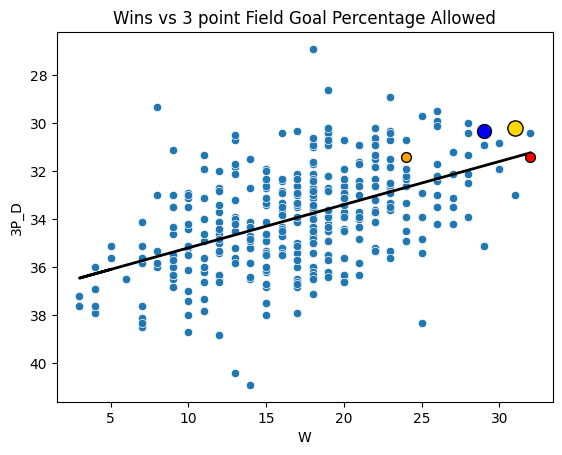

In [62]:
# Plot every team
sns.scatterplot(data=cbb26, x="W", y="3P_D")
plt.title("Wins vs 3 point Field Goal Percentage Allowed")

# Trendline
x = cbb26["W"]
y = cbb26["3P_D"]

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='black', linewidth=2)

# Highlight Michigan
michigan = cbb26[cbb26["TEAM"] == "Michigan"]
plt.scatter(
    michigan["W"],
    michigan["3P_D"],
    color="gold",
    edgecolors="black",
    s=120,
    zorder=10
)

# Highlight UConn
uconn = cbb26[cbb26["TEAM"] == "Connecticut"]
plt.scatter(
    uconn["W"],
    uconn["3P_D"],
    color="blue",
    edgecolors="black",
    s=100,
    zorder=10
)

# Highlight Arizona
arizona = cbb26[cbb26["TEAM"] == "Arizona"]
plt.scatter(
    arizona["W"],
    arizona["3P_D"],
    color="red",
    edgecolors="black",
    s=50,
    zorder=10
)

# Highlight Illinois
illinois = cbb26[cbb26["TEAM"] == "Illinois"]
plt.scatter(
    illinois["W"],
    illinois["3P_D"],
    color="orange",
    edgecolors="black",
    s=50,
    zorder=10
)

plt.gca().invert_yaxis()

This scatterplot shows a negative relationship between wins and 3-point Field Goal Percentage Allowed. Teams that did a better job defending the 3-point line generally had more wins. This suggests that preventing opponents from making 3-point shots was an important part of successful teams.

**What Team had the Best Three Point Field Goal Percentage Allowed in a Power Conference in 2026?**

In [63]:
top_3pd = powercbb26.sort_values(by="3P_D", ascending=True)
print("20 Best Three Point Field Goal Percentage Allowed")
print(top_3pd[["SEED", "CONF", "W", "TEAM", "3P_D"]].head(20))

20 Best Three Point Field Goal Percentage Allowed
    SEED CONF   W           TEAM  3P_D
19   4.0  B10  26       Nebraska  29.9
1    1.0  B10  31       Michigan  30.2
8    2.0   BE  29    Connecticut  30.3
0    1.0  ACC  32           Duke  30.4
15   6.0  SEC  22      Tennessee  30.6
52   NaN  ACC  19  Virginia Tech  30.6
21   4.0  B12  23         Kansas  30.7
13   3.0  ACC  29       Virginia  30.9
67   NaN  ACC  21     California  30.9
65   NaN  B10  18            USC  30.9
31   NaN  B12  18     Cincinnati  31.0
14   5.0   BE  28     St. John's  31.3
5    3.0  B10  24       Illinois  31.4
2    1.0  B12  32        Arizona  31.4
11   5.0  B12  22     Texas Tech  31.5
22   8.0  B10  21       Ohio St.  31.6
30   7.0  SEC  21       Kentucky  31.6
39  10.0  SEC  21      Texas A&M  31.7
18   4.0  SEC  26       Arkansas  31.7
23   7.0  B10  23           UCLA  31.8


This ranking shows the 20 teams that allowed the lowest 3-point Field Goal Percentage in a Power Conference. Many highly successful teams appear near the top, including Michigan, Connecticut, Duke, Arizona, and Illinois. This suggests that defending the 3-point line was an important part of many successful teams' defenses.

**What Team had the Worst Three Point Field Goal Percentage Allowed in a Power Conference in 2026?**

In [64]:
worst_3pd = powercbb26.sort_values(by="3P_D", ascending=False)
print("10 Worst Three Point Field Goal Percentage Allowed")
print(worst_3pd[["SEED", "CONF", "W", "TEAM", "3P_D"]].head(10))

10 Worst Three Point Field Goal Percentage Allowed
     SEED CONF   W          TEAM  3P_D
140   NaN  B10  12      Penn St.  38.8
75    NaN  B12  17      Colorado  36.8
45   10.0  SEC  20      Missouri  36.5
40    NaN  SEC  17        Auburn  36.5
112   NaN  B10  12      Maryland  36.3
44   11.0  SEC  18         Texas  36.0
116   NaN  B10  14       Rutgers  35.8
37   11.0  ACC  20    N.C. State  35.6
46    NaN  B12  16        Baylor  35.5
74    NaN  B12  19  Oklahoma St.  35.5


This ranking shows the 10 teams that allowed the highest 3-point Field Goal Percentage in a Power Conference. Most of these teams were not highly seeded, although Missouri and N.C. State were able to have successful seasons. This suggests that allowing opponents to shoot well from three can make winning more difficult.

**Adjusted Tempo:**

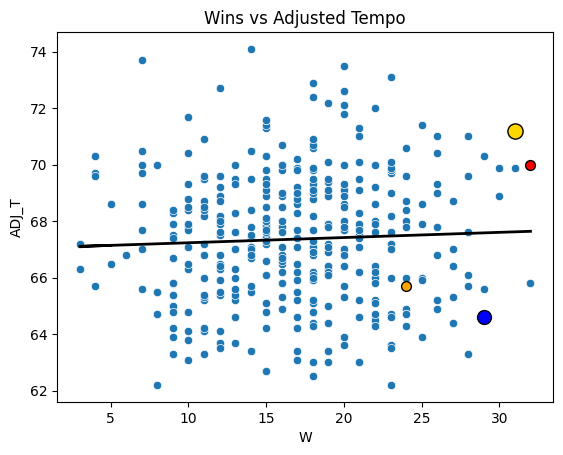

In [65]:
# Plot every team
sns.scatterplot(data=cbb26, x="W", y="ADJ_T")
plt.title("Wins vs Adjusted Tempo")

# Trendline
x = cbb26["W"]
y = cbb26["ADJ_T"]

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='black', linewidth=2)

# Highlight Michigan
michigan = cbb26[cbb26["TEAM"] == "Michigan"]
plt.scatter(
    michigan["W"],
    michigan["ADJ_T"],
    color="gold",
    edgecolors="black",
    s=120,
    zorder=10
)

# Highlight UConn
uconn = cbb26[cbb26["TEAM"] == "Connecticut"]
plt.scatter(
    uconn["W"],
    uconn["ADJ_T"],
    color="blue",
    edgecolors="black",
    s=100,
    zorder=10
)

# Highlight Arizona
arizona = cbb26[cbb26["TEAM"] == "Arizona"]
plt.scatter(
    arizona["W"],
    arizona["ADJ_T"],
    color="red",
    edgecolors="black",
    s=50,
    zorder=10
)

# Highlight Illinois
illinois = cbb26[cbb26["TEAM"] == "Illinois"]
plt.scatter(
    illinois["W"],
    illinois["ADJ_T"],
    color="orange",
    edgecolors="black",
    s=50,
    zorder=10
)

This scatterplot shows very little relationship between wins and Adjusted Tempo. Teams that played fast were not necessarily more successful than teams that played slowly. This suggests that the pace a team plays at is much less important to winning than how efficiently they play.

**What Team Played with the Fastest Pace in a Power Conference in 2026?**

In [66]:
top_adjt = powercbb26.sort_values(by="ADJ_T", ascending=False)
print("20 Best Adjusted Tempo")
print(top_adjt[["SEED", "CONF", "W", "TEAM", "ADJ_T"]].head(20))

20 Best Adjusted Tempo
     SEED CONF   W             TEAM  ADJ_T
17    4.0  SEC  23          Alabama   73.1
101   NaN  B12  12       Kansas St.   72.7
74    NaN  B12  19     Oklahoma St.   72.2
36    8.0  SEC  22          Georgia   72.0
73    NaN   BE  15       Providence   71.3
1     1.0  B10  31         Michigan   71.2
39   10.0  SEC  21        Texas A&M   71.0
18    4.0  SEC  26         Arkansas   71.0
161   NaN  ACC  11     Georgia Tech   70.9
65    NaN  B10  18              USC   70.7
50    NaN  ACC  18      Florida St.   70.6
3     1.0  SEC  26          Florida   70.4
93    NaN   BE  15           Xavier   70.3
2     1.0  B12  32          Arizona   70.0
32    6.0  B12  23              BYU   69.8
16    6.0  ACC  23       Louisville   69.7
14    5.0   BE  28       St. John's   69.6
98    NaN  SEC  13  Mississippi St.   69.5
60    NaN  B12  17      Arizona St.   69.2
76    NaN   BE  12        Marquette   69.2


This ranking shows the 20 teams with the highest Adjusted Tempo in a Power Conference. There is a wide variety of teams in this ranking, including both highly successful teams and teams that did not make the NCAA Tournament. This suggests that playing at a fast pace does not have a strong relationship with winning.

**What Team Played with the Slowest Pace in a Power Conference in 2026?**

In [67]:
worst_adjt = powercbb26.sort_values(by="ADJ_T", ascending=True)
print("10 Worst Adjusted Tempo")
print(worst_adjt[["SEED", "CONF", "W", "TEAM", "ADJ_T"]].head(10))

10 Worst Adjusted Tempo
     SEED CONF   W           TEAM  ADJ_T
61    NaN  B12  18  West Virginia   62.5
56    NaN  B10  15      Minnesota   62.7
25    9.0  B10  21           Iowa   63.0
4     2.0  B12  28        Houston   63.3
102   NaN  ACC  13     Pittsburgh   63.7
29    8.0  ACC  24        Clemson   64.3
7     2.0  B10  27         Purdue   64.4
8     2.0   BE  29    Connecticut   64.6
23    7.0  B10  23           UCLA   64.7
35    8.0   BE  24      Villanova   64.9


This ranking shows the 10 teams with the lowest Adjusted Tempo in a Power Conference. There are several successful teams in this ranking, including Houston, Purdue, Connecticut, and UCLA. This shows that teams can be very successful while playing at a slower pace.

**Wins Above Bubble:**

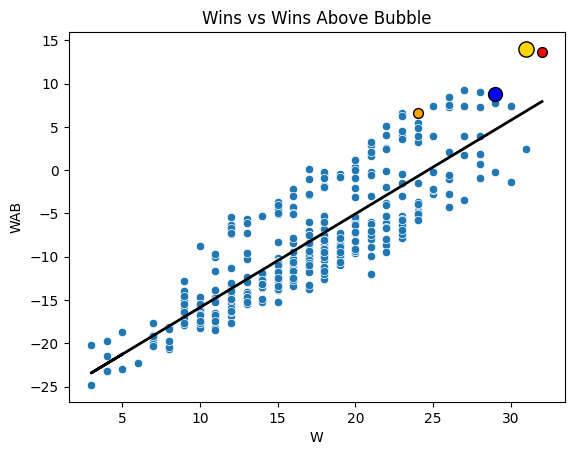

In [68]:
# Plot every team
sns.scatterplot(data=cbb26, x="W", y="WAB")
plt.title("Wins vs Wins Above Bubble")

# Trendline
x = cbb26["W"]
y = cbb26["WAB"]

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='black', linewidth=2)

# Highlight Michigan
michigan = cbb26[cbb26["TEAM"] == "Michigan"]
plt.scatter(
    michigan["W"],
    michigan["WAB"],
    color="gold",
    edgecolors="black",
    s=120,
    zorder=10
)

# Highlight UConn
uconn = cbb26[cbb26["TEAM"] == "Connecticut"]
plt.scatter(
    uconn["W"],
    uconn["WAB"],
    color="blue",
    edgecolors="black",
    s=100,
    zorder=10
)

# Highlight Arizona
arizona = cbb26[cbb26["TEAM"] == "Arizona"]
plt.scatter(
    arizona["W"],
    arizona["WAB"],
    color="red",
    edgecolors="black",
    s=50,
    zorder=10
)

# Highlight Illinois
illinois = cbb26[cbb26["TEAM"] == "Illinois"]
plt.scatter(
    illinois["W"],
    illinois["WAB"],
    color="orange",
    edgecolors="black",
    s=50,
    zorder=10
)

This scatterplot shows a very strong positive relationship between wins and Wins Above Bubble. Teams with higher Wins Above Bubble values generally had significantly more wins. The Final Four teams were all toward the top of the graph, showing a strong connection between this statistic and team success.

**What Team had the Most Wins above Bubble in a Power Conference in 2026?**

In [69]:
top_wab = powercbb26.sort_values(by="WAB", ascending=False)
print("20 Most Wins above Bubble")
print(top_wab[["SEED", "CONF", "W", "TEAM", "WAB"]].head(20))

20 Most Wins above Bubble
    SEED CONF   W            TEAM   WAB
1    1.0  B10  31        Michigan  14.0
0    1.0  ACC  32            Duke  13.7
2    1.0  B12  32         Arizona  13.7
7    2.0  B10  27          Purdue   9.2
4    2.0  B12  28         Houston   9.0
8    2.0   BE  29     Connecticut   8.8
3    1.0  SEC  26         Florida   8.5
13   3.0  ACC  29        Virginia   7.8
19   4.0  B10  26        Nebraska   7.5
18   4.0  SEC  26        Arkansas   7.5
6    2.0  B12  27        Iowa St.   7.4
12   3.0  B10  25    Michigan St.   7.4
14   5.0   BE  28      St. John's   7.3
9    5.0  SEC  26      Vanderbilt   7.3
5    3.0  B10  24        Illinois   6.6
17   4.0  SEC  23         Alabama   6.6
21   4.0  B12  23          Kansas   6.3
20   5.0  B10  24       Wisconsin   5.4
11   5.0  B12  22      Texas Tech   5.1
26   6.0  ACC  24  North Carolina   4.9


This ranking shows the 20 teams with the most Wins Above Bubble in a Power Conference. The top three teams were Michigan, Duke, and Arizona, and all three were number one seeds. Almost every team in the top 20 was a top five seed, showing a very strong relationship between Wins Above Bubble and team success.

**What Team had the Least Wins above Bubble in a Power Conference in 2026?**

In [70]:
worst_wab = powercbb26.sort_values(by="WAB", ascending=True)
print("10 Worst Wins above Bubble")
print(worst_wab[["SEED", "CONF", "W", "TEAM", "WAB"]].head(10))

10 Worst Wins above Bubble
     SEED CONF   W            TEAM   WAB
138   NaN  ACC  11  Boston College -10.0
161   NaN  ACC  11    Georgia Tech  -9.7
114   NaN  B12  10            Utah  -8.8
76    NaN   BE  12       Marquette  -7.4
102   NaN  ACC  13      Pittsburgh  -7.2
140   NaN  B10  12        Penn St.  -7.2
101   NaN  B12  12      Kansas St.  -6.7
89    NaN  B10  12          Oregon  -6.3
99    NaN  SEC  13  South Carolina  -6.1
96    NaN  ACC  13      Notre Dame  -5.6


This ranking shows the 10 teams with the lowest Wins Above Bubble in a Power Conference. None of these teams made the NCAA Tournament, and all had negative Wins Above Bubble numbers. This shows that teams with low Wins Above Bubble numbers were generally much less successful during the 2026 season.

**Heatmap of College Basketball Statistics from the 2026 Season:**

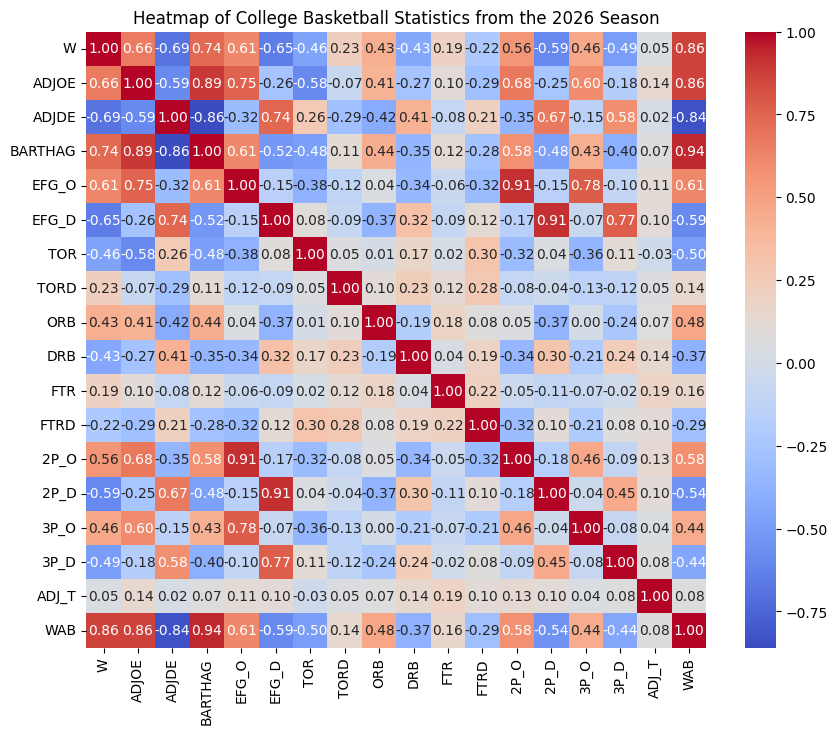

In [71]:
# Select the stats you want to compare
stats = cbb26[["W", "ADJOE", "ADJDE", "BARTHAG", "EFG_O", "EFG_D", "TOR", "TORD", "ORB", "DRB", "FTR", "FTRD", "2P_O", "2P_D", "3P_O", "3P_D", "ADJ_T", "WAB"]]

# Create correlation matrix
corr = stats.corr()

# Make heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Heatmap of College Basketball Statistics from the 2026 Season")
plt.show()

The heatmap shows that some statistics have a much stronger relationship with wins than others. Wins Above Bubble and BARTHAG had the strongest positive relationships with wins, while Adjusted Defensive Efficiency and Effective Field Goal Percentage Allowed had the strongest negative relationships. Adjusted Tempo had almost no relationship with wins, suggesting that the pace a team plays at is not strongly related to its number of wins.

**Ranking of How Each Statistic Relates to Wins:**
1. Wins Above Bubble: 0.86
2. BARTHAG: 0.74
3. Adjusted Defensive Efficiency: -0.69
4. Adjusted Offensive Efficiency: 0.66
5. Effective Field Goal Percentage Allowed: -0.65
6. Effective Field Goal Percentage: 0.61
7. 2 Point Field Goal Percentage Allowed: -0.59
8. 2 Point Field Goal Percentage: 0.56
9. 3 Point Field Goal Percentage Allowed: -0.49
10. 3 Point Field Goal Percentage: 0.46
11. Turnover Rate: -0.46
12. Defensive Rebounding: -0.43
13. Offensive Rebounding: 0.43
14. Turnover Rate Allowed: 0.23
15. Free Throw Rate Allowed: -0.22
16. Free Throw Rate: 0.19
17. Adjusted Tempo: 0.05

Note: A negative correlation does not mean the statistic is bad. For statistics such as Adjusted Defensive Efficiency and Effective Field Goal Percentage Allowed, a negative correlation means that lower values are associated with more wins.

**Conclusion**

Overall, this project looked at 17 different college basketball statistics to determine which factors were most closely related to winning during the 2026 season. The results showed that overall team strength, offensive efficiency, defensive efficiency, and shooting efficiency had the strongest relationships with wins. Wins Above Bubble had the strongest correlation with wins at 0.86, followed by BARTHAG at 0.74, Adjusted Defensive Efficiency at -0.69, Adjusted Offensive Efficiency at 0.66, and Effective Field Goal Percentage Allowed at -0.65. The scatterplots and rankings also showed that many of the most successful teams performed well in several of these areas rather than relying on one specific statistic. On the other hand, statistics such as free throw rate, turnover rate allowed, and especially Adjusted Tempo had much weaker relationships with wins. This suggests that the pace a team plays at is not nearly as important as how efficiently that team performs on offense and defense. Overall, the data suggests that successful college basketball teams are generally teams that consistently score efficiently, defend efficiently, and perform well in multiple areas of the game. While these correlations cannot prove that any statistic directly causes a team to win, they provide a strong picture of which factors were most closely associated with winning in the 2026 season.